# COPC Access in R with `lasR` on MAAP — Previous Method vs Efficient COPC Method

## Dataset: MAAP `GEDI_CalVal_Lidar_COPC`

This notebook demonstrates **two approaches** for working with LiDAR COPC data on MAAP:

1. **Approach 1 — Previous method:** download the full point-cloud file first, then process it locally.
2. **Approach 2 — Efficient method:** read the cloud-hosted COPC file directly using `lasR` and GDAL VSI paths such as `/vsis3/` and `/vsicurl/`.

The goal is to show why COPC is useful for cloud workflows. With the previous method, the entire file is transferred before analysis. With the COPC method, MAAP can request only metadata or only a selected spatial area from the cloud-hosted point cloud.

> **Environment:** This notebook is intended for a MAAP R workspace with `lasR`, GDAL, `sf`, `terra`, `rstac`, `ggplot2`, and `dplyr` available.

> **Custom lasR image note:** At the time of testing, the required `lasR` environment was not available in the default MAAP Hub image. A custom workspace image was built through **Build your own image** in MAAP Hub using the `GEO-TREES/workspace_images` repository and the `lasR` branch.

To use the same custom image setup:

1. Open the MAAP Hub: `https://hub.maap-project.org/hub/`
2. Select **Build your own image**
3. Use repository: `GEO-TREES/workspace_images`
4. Use branch: `lasR`
5. Build and launch the custom image

> **Current VPC status note:** A VPC example is included later in this notebook, but it is disabled by default because `write_vpc()` is not yet working for the remote COPC paths tested in this custom `lasR` image. The notebook keeps the VPC code so it can be enabled once the `lasR` / LASlib remote-read issue is resolved.

## 1. Setup

This section loads the required R packages and sets GDAL environment options for remote cloud reads.

The GDAL VSI settings are most important for **Approach 2**, where the file is read directly from cloud storage.




In [8]:
# Load lasR and configure GDAL VSI settings
library(lasR)

cat("lasR version:", as.character(packageVersion("lasR")), "
")
cat("lasR loaded OK
")

# GDAL / VSI environment variables for public S3 and remote range reads.
# 2 MB = 2 * 1024 * 1024 = 2097152 bytes.
vsi_chunk_size_bytes <- 2 * 1024 * 1024

Sys.setenv(
  AWS_NO_SIGN_REQUEST                = "YES",
  GDAL_HTTP_MERGE_CONSECUTIVE_RANGES = "YES",
  CPL_VSIL_CURL_CHUNK_SIZE           = as.character(vsi_chunk_size_bytes),
  CPL_VSIL_CURL_CACHE_SIZE           = "67108864",
  GDAL_HTTP_CONNECTTIMEOUT           = "30",
  GDAL_HTTP_TIMEOUT                  = "120"
)

cat("GDAL VSI environment variables set
")
cat("CPL_VSIL_CURL_CHUNK_SIZE:", Sys.getenv("CPL_VSIL_CURL_CHUNK_SIZE"), "bytes
")
cat("Chunk size in MB:", vsi_chunk_size_bytes / 1024^2, "MB
")



Attaching package: ‘lasR’


The following object is masked from ‘package:dplyr’:

    summarise


The following objects are masked from ‘package:terra’:

    focal, rasterize




lasR version: 0.20.0 
lasR loaded OK
GDAL VSI environment variables set
CPL_VSIL_CURL_CHUNK_SIZE: 2097152 bytes
Chunk size in MB: 2 MB


In [9]:
# Install or verify supporting R packages
# This setup cell is tagged as hidden input in the notebook metadata.
required_pkgs <- c("rstac", "sf", "terra", "ggplot2", "dplyr")
missing_pkgs <- required_pkgs[!vapply(required_pkgs, requireNamespace, logical(1), quietly = TRUE)]

if (length(missing_pkgs) > 0) {
  install.packages(missing_pkgs, repos = "https://cloud.r-project.org")
}

library(rstac)
library(sf)
library(terra)
library(ggplot2)
library(dplyr)

cat("Package setup complete
")


Package setup complete


## 1A. Helper functions

The helper functions are separated into their own code block so the main workflow cells stay easier to read.


In [10]:
# Helper functions used throughout the notebook
first_non_null <- function(...) {
  values <- list(...)
  values <- values[!vapply(values, is.null, logical(1))]
  if (length(values) == 0) return(NULL)
  values[[1]]
}

get_asset_href <- function(feat) {
  assets <- feat$assets
  first_asset_href <- if (length(assets) > 0) assets[[1]]$href else NULL
  first_non_null(
    assets$data$href,
    assets$copc$href,
    first_asset_href
  )
}

build_vsi_uri <- function(href) {
  if (startsWith(href, "s3://")) {
    paste0("/vsis3/", sub("^s3://", "", href))
  } else if (startsWith(href, "https://")) {
    paste0("/vsicurl/", href)
  } else {
    href
  }
}

s3_to_https <- function(href) {
  if (!startsWith(href, "s3://")) return(href)
  no_scheme <- sub("^s3://", "", href)
  bucket <- sub("/.*$", "", no_scheme)
  key <- sub("^[^/]+/", "", no_scheme)
  paste0("https://", bucket, ".s3.amazonaws.com/", key)
}

timings <- data.frame(
  step = character(),
  seconds = numeric(),
  stringsAsFactors = FALSE
)

record_timing <- function(step, elapsed) {
  timings <<- rbind(
    timings,
    data.frame(step = step, seconds = as.numeric(elapsed), stringsAsFactors = FALSE)
  )
  invisible(timings)
}


## 2. Discover a COPC file from MAAP STAC

Both approaches use the same source data.

This section queries the MAAP STAC API for the `GEDI_CalVal_Lidar_COPC` collection, extracts a COPC asset URL, and prepares two forms of the path:

- **Download URL:** used by the previous method to download the complete file locally.
- **GDAL VSI URL:** used by the efficient method to read the COPC file directly from cloud storage.

A small STAC footprint overview is also created from item bounding boxes. This gives a lightweight catalogue-level visualization without reading the full point-cloud data.


In [11]:
# Query MAAP STAC for COPC items
stac_api <- "https://stac.maap-project.org"
collection_id <- "GEDI_CalVal_Lidar_COPC"

items <- stac(stac_api) |>
  collections(collection_id) |>
  items(limit = 10) |>
  get_request()

cat(sprintf("Collection:     %s
", collection_id))
cat(sprintf("Items returned: %d
", length(items$features)))

# Extract item ID, asset href, and bbox
item_info <- lapply(items$features, function(feat) {
  href <- get_asset_href(feat)
  list(id = feat$id, href = href, bbox = feat$bbox)
})

all_hrefs <- vapply(item_info, function(it) it$href, character(1))
all_uris  <- vapply(all_hrefs, build_vsi_uri, character(1))

# Select one test item
test_item <- item_info[[1]]
test_href <- test_item$href
test_uri  <- build_vsi_uri(test_href)
test_download_url <- s3_to_https(test_href)

cat("
Selected test item:
")
cat("  ID:             ", test_item$id, "
")
cat("  Original href:  ", test_href, "
")
cat("  Download URL:   ", test_download_url, "
")
cat("  GDAL VSI path:  ", test_uri, "
")


Collection:     GEDI_CalVal_Lidar_COPC
Items returned: 10

Selected test item:
  ID:              usa_tepeecreek_2809704010602 
  Original href:   s3://nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 
  Download URL:    https://nasa-maap-data-store.s3.amazonaws.com/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 
  GDAL VSI path:   /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 


## 2A. Lightweight catalogue overview from STAC bounding boxes

This plot uses only the STAC item bounding boxes. It does **not** download or read the full COPC files. It is a quick way to show which tiles are being considered before running any point-cloud processing.

Some COPC STAC items return a **3D bounding box** in the form `xmin, ymin, zmin, xmax, ymax, zmax`. The plotting code below handles both 2D and 3D STAC bbox formats so elevation values are not accidentally plotted as longitude or latitude.


Simple feature collection with 10 features and 1 field
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -116.4143 ymin: 47.79506 xmax: -116.195 ymax: 47.83994
Geodetic CRS:  WGS 84
                        item_id                       geometry
1  usa_tepeecreek_2809704010602 POLYGON ((-116.2178 47.8075...
2  usa_tepeecreek_2809702010602 POLYGON ((-116.2192 47.8084...
3  usa_tepeecreek_2809700010602 POLYGON ((-116.2106 47.8062...
4  usa_tepeecreek_2809698010602 POLYGON ((-116.2026 47.8345...
5  usa_tepeecreek_2809696010602 POLYGON ((-116.2009 47.8359...
6  usa_tepeecreek_2809694010602 POLYGON ((-116.2644 47.8204...
7  usa_tepeecreek_2809692010602 POLYGON ((-116.4112 47.8059...
8  usa_tepeecreek_2809690010602 POLYGON ((-116.4126 47.8127...
9  usa_tepeecreek_2809688010602 POLYGON ((-116.2126 47.7950...
10 usa_tepeecreek_2809686010602 POLYGON ((-116.4143 47.8076...


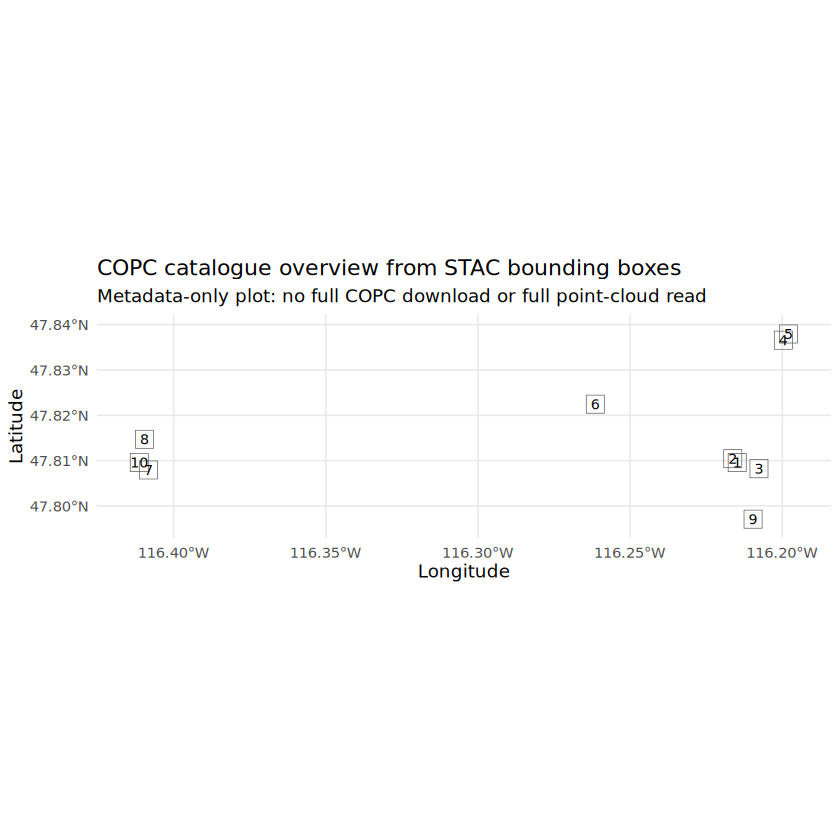

In [12]:

# This handles both common STAC bbox formats:
#   2D bbox: xmin, ymin, xmax, ymax
#   3D bbox: xmin, ymin, zmin, xmax, ymax, zmax
# The earlier warning happened because a 3D bbox elevation value was being read as xmax.

bbox_to_xy <- function(bbox) {
  bbox <- as.numeric(unlist(bbox))
  
  if (length(bbox) == 4) {
    return(list(xmin = bbox[1], ymin = bbox[2], xmax = bbox[3], ymax = bbox[4]))
  }
  
  if (length(bbox) == 6) {
    return(list(xmin = bbox[1], ymin = bbox[2], xmax = bbox[4], ymax = bbox[5]))
  }
  
  stop(sprintf("Unsupported bbox length: %d", length(bbox)))
}

bbox_to_sf <- function(it) {
  b <- bbox_to_xy(it$bbox)
  geom <- sf::st_polygon(list(matrix(
    c(
      b$xmin, b$ymin,
      b$xmax, b$ymin,
      b$xmax, b$ymax,
      b$xmin, b$ymax,
      b$xmin, b$ymin
    ),
    ncol = 2,
    byrow = TRUE
  )))
  sf::st_sf(item_id = it$id, geometry = sf::st_sfc(geom, crs = 4326))
}

bbox_sf <- do.call(rbind, lapply(item_info, bbox_to_sf))

# Quick sanity check: longitude should be within [-180, 180] and latitude within [-90, 90].
print(bbox_sf[, "item_id"])

bbox_centers <- sf::st_coordinates(sf::st_centroid(sf::st_geometry(bbox_sf)))
bbox_labels <- data.frame(
  item_number = seq_len(nrow(bbox_sf)),
  lon = bbox_centers[, 1],
  lat = bbox_centers[, 2]
)

ggplot() +
  geom_sf(data = bbox_sf, fill = NA) +
  geom_text(
    data = bbox_labels,
    aes(x = lon, y = lat, label = item_number),
    size = 3
  ) +
  coord_sf(expand = TRUE) +
  labs(
    title = "COPC catalogue overview from STAC bounding boxes",
    subtitle = "Metadata-only plot: no full COPC download or full point-cloud read",
    x = "Longitude",
    y = "Latitude"
  ) +
  theme_minimal()


## Approach 1 — Previous Method: Download Full File First, Then Process Locally

In the previous method, the complete `.copc.laz` or `.laz` file is downloaded into the MAAP workspace before any analysis is done.

This is simple and familiar, but it is not efficient for large LiDAR datasets because the entire file must be transferred even when the analysis only needs a small area.

**Workflow:**

1. Get the file URL from STAC.
2. Download the complete file to local storage.
3. Open the local file using `lasR`.
4. Run header summary or spatial subset operations on the local file.
5. Delete the local file if it is no longer needed.

> The code below uses a safety flag so the notebook does not accidentally download a large file. Set `run_full_download <- TRUE` when you want to run this comparison.


In [13]:
# Approach 1 configuration
# Set this to TRUE only when you intentionally want to demonstrate the previous full-download method.
run_full_download <- TRUE

local_dir <- file.path(tempdir(), "maap_copc_download_demo")
dir.create(local_dir, showWarnings = FALSE, recursive = TRUE)

local_copc <- file.path(local_dir, basename(test_href))

cat("Previous-method local file path:\n")
cat(local_copc, "\n")
cat("\nrun_full_download is currently:", run_full_download, "\n")


Previous-method local file path:
/tmp/RtmpdT10Vu/maap_copc_download_demo/usa_tepeecreek_2809704010602.copc.laz 

run_full_download is currently: TRUE 


In [14]:
# Approach 1A: Download the complete COPC file locally
if (run_full_download) {
  cat("Downloading full COPC file...\n")
  cat("Source:     ", test_download_url, "\n")
  cat("Destination:", local_copc, "\n\n")
  
  t0 <- proc.time()
  download.file(test_download_url, destfile = local_copc, mode = "wb", quiet = FALSE)
  download_time <- (proc.time() - t0)["elapsed"]
  record_timing("Approach 1A: full download", download_time)
  
  local_size_mb <- file.info(local_copc)$size / 1024^2
  cat(sprintf("\nDownload complete in %.1f seconds\n", download_time))
  cat(sprintf("Local file size: %.2f MB\n", local_size_mb))
} else {
  cat("Skipped full download. Set run_full_download <- TRUE to run this cell.\n")
}


Source:      https://nasa-maap-data-store.s3.amazonaws.com/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 
Destination: /tmp/RtmpdT10Vu/maap_copc_download_demo/usa_tepeecreek_2809704010602.copc.laz 


Download complete in 0.4 seconds
Local file size: 15.57 MB


In [15]:
# Approach 1B: Read the locally downloaded file with lasR
if (run_full_download && file.exists(local_copc)) {
  cat("Reading local file header/summary after full download...\n")
  
  t0 <- proc.time()
  local_summary <- exec(reader(copc_depth = 0L) + lasR::summarise(), on = local_copc)
  local_header_time <- (proc.time() - t0)["elapsed"]
  record_timing("Approach 1B: local header summary", local_header_time)
  
  cat(sprintf("Local header read complete in %.1f seconds\n", local_header_time))
  print(local_summary)
} else {
  cat("Local file is not available. Run the download cell first.\n")
}


Reading local file header/summary after full download...
Local header read complete in 0.1 seconds
$npoints
[1] 79321

$nsingle
[1] 31321

$nwithheld
[1] 0

$nsynthetic
[1] 0

$npoints_per_return
    1     2     3     4     5     6     7 
52327 19565  5977  1326   119     6     1 

$npoints_per_class
    1     2 
61277 18044 

$z_histogram
1360.000000 1362.000000 1364.000000 1366.000000 1368.000000 1370.000000 
         10          58          62         142         247         263 
1372.000000 1374.000000 1376.000000 1378.000000 1380.000000 1382.000000 
        422         596         587         768         927         788 
1384.000000 1386.000000 1388.000000 1390.000000 1392.000000 1394.000000 
       1113        1151        1098        1443        1745        1555 
1396.000000 1398.000000 1400.000000 1402.000000 1404.000000 1406.000000 
       1989        2055        1880        2333        2267        2127 
1408.000000 1410.000000 1412.000000 1414.000000 1416.000000 1418.000000 
 

In [16]:
# Approach 1C: Spatial subset after downloading the full file
# The subset is local, but the full file had to be downloaded first.
xmin <- 558600; xmax <- 558900
ymin <- 5295200; ymax <- 5295500

if (run_full_download && file.exists(local_copc)) {
  cat("Reading 300 m x 300 m spatial subset from local file...\n")
  
  t0 <- proc.time()
  local_subset <- exec(
    reader_rectangles(
      xmin = xmin, ymin = ymin,
      xmax = xmax, ymax = ymax
    ) + lasR::summarise(),
    on = local_copc
  )
  local_subset_time <- (proc.time() - t0)["elapsed"]
  record_timing("Approach 1C: local spatial subset", local_subset_time)
  
  cat(sprintf("Local spatial subset complete in %.1f seconds\n", local_subset_time))
  print(local_subset)
} else {
  cat("Local file is not available. Run the download cell first.\n")
}


Reading 300 m x 300 m spatial subset from local file...
Local spatial subset complete in 1.8 seconds
$npoints
[1] 1409855

$nsingle
[1] 765139

$nwithheld
[1] 0

$nsynthetic
[1] 0

$npoints_per_return
      1       2       3       4       5       6       7 
1040208  275180   79544   13632    1245      44       2 

$npoints_per_class
     1      2 
862168 547687 

$z_histogram
1360.000000 1362.000000 1364.000000 1366.000000 1368.000000 1370.000000 
        472        3154        4336        3330        4334        5234 
1372.000000 1374.000000 1376.000000 1378.000000 1380.000000 1382.000000 
       5488        8750       11883       13619       15363       15590 
1384.000000 1386.000000 1388.000000 1390.000000 1392.000000 1394.000000 
      17637       18898       21239       27806       32482       34852 
1396.000000 1398.000000 1400.000000 1402.000000 1404.000000 1406.000000 
      36783       38385       40016       40424       41100       44719 
1408.000000 1410.000000 1412.000000 1

## Interpretation of Approach 1

This method is useful as a baseline because it shows the older pattern:

> **Transfer the whole point cloud first, then process it.**

Even when the analysis only needs a 300 m × 300 m region, the full file is still downloaded before the subset can be read. For large LiDAR collections, this creates extra transfer time, storage use, and repeated I/O.


## Approach 2 — Efficient Method: Read Remote COPC Directly with `lasR`

In the efficient method, the COPC file stays in cloud storage. `lasR` reads it using a GDAL VSI path such as `/vsis3/...`.

This method is more efficient because COPC is spatially indexed. Instead of downloading the full file, `lasR` can request only the header or the selected spatial region.

**Workflow:**

1. Get the COPC asset URL from STAC.
2. Convert the cloud URL to a GDAL VSI path.
3. Read header metadata using `copc_depth = 0L`.
4. Read only the required spatial subset using `reader_rectangles()`.
5. Generate derived products such as DTM and CHM from the subset.


## COPC depth syntax used by `lasR`

The expression `0L` is R syntax for the integer value `0`. In this notebook, `reader(copc_depth = 0L)` is used for a very shallow COPC read that is useful for checking the remote file and getting a quick summary/header-style overview.

In general:

- `copc_depth = 0L` gives the shallowest COPC overview.
- Larger integer values such as `1L` or `2L` ask for deeper COPC hierarchy levels and can give a coarser sampled overview without forcing a full-detail read.
- `copc_depth = NULL` is used in the subset/derived-product cells where the spatial window should be processed at the needed detail rather than only at a shallow overview level.

Reference for the related VPC workflow: https://r-lidar.github.io/lasR/reference/write_vpc.html?q=vpc#references


In [17]:
# Approach 2A: Header-only read directly from remote COPC
cat("Remote COPC path:\n")
cat(test_uri, "\n\n")

cat("Reading header only from remote COPC...\n")
t0 <- proc.time()
remote_header <- exec(reader(copc_depth = 0L) + lasR::summarise(), on = test_uri)
remote_header_time <- (proc.time() - t0)["elapsed"]
record_timing("Approach 2A: remote header summary", remote_header_time)

cat(sprintf("Remote header read complete in %.1f seconds\n", remote_header_time))
print(remote_header)


Remote COPC path:
/vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 

Reading header only from remote COPC...
Remote header read complete in 0.4 seconds
$npoints
[1] 79321

$nsingle
[1] 31321

$nwithheld
[1] 0

$nsynthetic
[1] 0

$npoints_per_return
    1     2     3     4     5     6     7 
52327 19565  5977  1326   119     6     1 

$npoints_per_class
    1     2 
61277 18044 

$z_histogram
1360.000000 1362.000000 1364.000000 1366.000000 1368.000000 1370.000000 
         10          58          62         142         247         263 
1372.000000 1374.000000 1376.000000 1378.000000 1380.000000 1382.000000 
        422         596         587         768         927         788 
1384.000000 1386.000000 1388.000000 1390.000000 1392.000000 1394.000000 
       1113        1151        1098        1443        1745        1555 
1396.000000 1398.000000 1400.000000 1402.000000 1404.000000 1406.000000 
       1989        2055        1

In [18]:
# Extract projected CRS EPSG from the header when possible
# Some compound CRS strings return EPSG 0 directly, so this parses the projected CRS block.
wkt <- remote_header$crs

projcs_block <- tryCatch(
  sub(".*?(PROJCS\\[.*?\\]),VERT_CS.*", "\\1", wkt, perl = TRUE),
  error = function(e) NA_character_
)

epsg_hits <- tryCatch(
  regmatches(
    projcs_block,
    gregexpr('(?<=AUTHORITY\\["EPSG",")\\d+(?="\\])', projcs_block, perl = TRUE)
  )[[1]],
  error = function(e) character(0)
)

tile_epsg <- if (length(epsg_hits) > 0) as.integer(tail(epsg_hits, 1)) else NA_integer_

cat("Projected CRS EPSG:", tile_epsg, "\n")
if (!is.na(tile_epsg)) {
  cat("CRS name:", sf::st_crs(tile_epsg)$Name, "\n")
}


Projected CRS EPSG: 3741 
CRS name: NAD83(HARN) / UTM zone 11N 


In [19]:
# Approach 2B: Spatial subset directly from remote COPC
# This reads only the selected window from the cloud-hosted COPC.
xmin <- 558600; xmax <- 558900
ymin <- 5295200; ymax <- 5295500

cat("Reading 300 m x 300 m subset directly from remote COPC...\n")

t0 <- proc.time()
remote_subset <- exec(
  reader_rectangles(
    xmin = xmin, ymin = ymin,
    xmax = xmax, ymax = ymax
  ) + lasR::summarise(),
  on = test_uri
)
remote_subset_time <- (proc.time() - t0)["elapsed"]
record_timing("Approach 2B: remote spatial subset", remote_subset_time)

cat(sprintf("Remote spatial subset complete in %.1f seconds\n", remote_subset_time))
print(remote_subset)


Reading 300 m x 300 m subset directly from remote COPC...
Remote spatial subset complete in 2.5 seconds
$npoints
[1] 1409855

$nsingle
[1] 765139

$nwithheld
[1] 0

$nsynthetic
[1] 0

$npoints_per_return
      1       2       3       4       5       6       7 
1040208  275180   79544   13632    1245      44       2 

$npoints_per_class
     1      2 
862168 547687 

$z_histogram
1360.000000 1362.000000 1364.000000 1366.000000 1368.000000 1370.000000 
        472        3154        4336        3330        4334        5234 
1372.000000 1374.000000 1376.000000 1378.000000 1380.000000 1382.000000 
       5488        8750       11883       13619       15363       15590 
1384.000000 1386.000000 1388.000000 1390.000000 1392.000000 1394.000000 
      17637       18898       21239       27806       32482       34852 
1396.000000 1398.000000 1400.000000 1402.000000 1404.000000 1406.000000 
      36783       38385       40016       40424       41100       44719 
1408.000000 1410.000000 1412.00000

In [20]:
# Optional: Full remote summary for comparison
# This may be slower because it asks lasR to summarize the full remote file.
run_full_remote_summary <- FALSE

if (run_full_remote_summary) {
  cat("Running full remote summary. This may take longer.\n")
  
  t0 <- proc.time()
  remote_full <- exec(reader() + lasR::summarise(), on = test_uri)
  remote_full_time <- (proc.time() - t0)["elapsed"]
  record_timing("Optional: full remote summary", remote_full_time)
  
  cat(sprintf("Full remote summary complete in %.1f seconds\n", remote_full_time))
  print(remote_full)
  
  if (exists("remote_subset") && !is.null(remote_subset$npoints) && !is.null(remote_full$npoints)) {
    cat(sprintf(
      "Fraction of file represented by subset: %.4f%%\n",
      100 * remote_subset$npoints / remote_full$npoints
    ))
  }
} else {
  cat("Skipped full remote summary. Set run_full_remote_summary <- TRUE if needed.\n")
}


Skipped full remote summary. Set run_full_remote_summary <- TRUE if needed.


## Interpretation of Approach 2

This method demonstrates the cloud-optimized workflow:

> **Keep the point cloud in cloud storage and read only what is needed.**

The header read checks the file without transferring the entire point cloud. The spatial subset read shows how `lasR` can access only the selected region from the remote COPC file. This is the key advantage over the previous full-download method.


## Approach 2C — Derived Products from Remote COPC Subset

After the efficient spatial read, the same subset can be used to create analysis products such as:

- **DTM:** Digital Terrain Model
- **CHM:** Canopy Height Model

These products are generated from the selected remote COPC window instead of from a full downloaded point cloud.


Computing DTM from remote COPC subset...
Output: /tmp/RtmpdT10Vu/usa_tepeecreek_2809704010602_dtm.tif 



class       : SpatRaster 
size        : 290, 301, 1  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 558600, 558901, 5295211, 5295501  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source      : usa_tepeecreek_2809704010602_dtm.tif 
name        : max 


DTM completed in 3.0 seconds
class       : SpatRaster 
size        : 289, 300, 1  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 558600, 558900, 5295211, 5295500  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source(s)   : memory
varname     : usa_tepeecreek_2809704010602_dtm 
name        :     max 
min value   : 1361.23 
max value   : 1488.53 


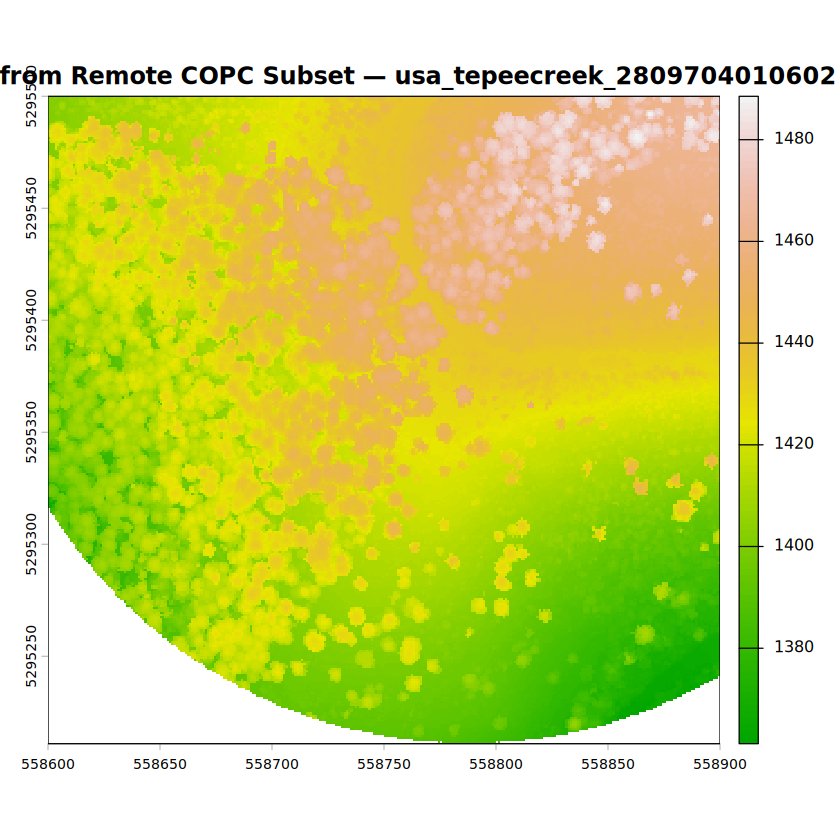

In [21]:
# DTM from remote COPC subset
library(lasR)
library(terra)

xmin <- 558600; xmax <- 558900
ymin <- 5295200; ymax <- 5295500

dtm_out <- file.path(tempdir(), paste0(test_item$id, "_dtm.tif"))
cat("Computing DTM from remote COPC subset...\n")
cat("Output:", dtm_out, "\n\n")

t0 <- proc.time()
pipeline_dtm <- reader_rectangles(
    xmin = xmin, ymin = ymin,
    xmax = xmax, ymax = ymax,
    copc_depth = NULL
  ) +
  triangulate(filter = keep_ground()) +
  lasR::rasterize(res = 1, method = "tin", ofile = dtm_out)

exec(pipeline_dtm, on = test_uri)
dtm_time <- (proc.time() - t0)["elapsed"]
record_timing("Approach 2C: DTM from remote subset", dtm_time)
cat(sprintf("\nDTM completed in %.1f seconds\n", dtm_time))

if (file.exists(dtm_out)) {
  dtm <- terra::rast(dtm_out)
  dtm <- terra::crop(dtm, terra::ext(xmin, xmax, ymin, ymax))
  print(dtm)
  terra::plot(
    dtm,
    main   = paste0("DTM from Remote COPC Subset — ", test_item$id),
    col    = terrain.colors(100),
    axes   = TRUE,
    legend = TRUE
  )
}


Computing CHM from remote COPC subset...
Output: /tmp/RtmpdT10Vu/usa_tepeecreek_2809704010602_chm.tif 



class       : SpatRaster 
size        : 578, 601, 1  (nrow, ncol, nlyr)
resolution  : 0.5, 0.5  (x, y)
extent      : 558600, 558900.5, 5295212, 5295500  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source      : usa_tepeecreek_2809704010602_chm.tif 
name        : max 


CHM completed in 3.8 seconds
class       : SpatRaster 
size        : 577, 600, 1  (nrow, ncol, nlyr)
resolution  : 0.5, 0.5  (x, y)
extent      : 558600, 558900, 5295212, 5295500  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source(s)   : memory
varname     : usa_tepeecreek_2809704010602_chm 
name        :   max 
min value   : -0.43 
max value   : 41.08 


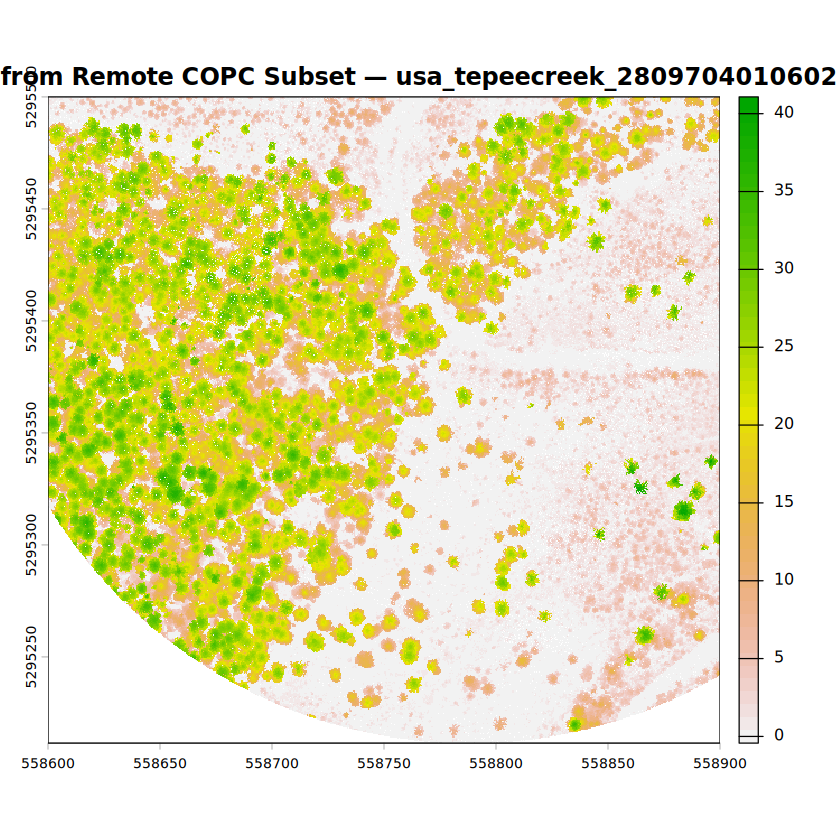

In [22]:
# CHM from remote COPC subset
library(lasR)
library(terra)

xmin <- 558600; xmax <- 558900
ymin <- 5295200; ymax <- 5295500

chm_out <- file.path(tempdir(), paste0(test_item$id, "_chm.tif"))
cat("Computing CHM from remote COPC subset...\n")
cat("Output:", chm_out, "\n\n")

t0 <- proc.time()
ground_tri <- triangulate(filter = keep_ground())

pipeline_chm <- reader_rectangles(
    xmin = xmin, ymin = ymin,
    xmax = xmax, ymax = ymax,
    copc_depth = NULL
  ) +
  ground_tri +
  transform_with(ground_tri) +
  lasR::rasterize(res = 0.5, method = "max", ofile = chm_out)

exec(pipeline_chm, on = test_uri)
chm_time <- (proc.time() - t0)["elapsed"]
record_timing("Approach 2C: CHM from remote subset", chm_time)
cat(sprintf("\nCHM completed in %.1f seconds\n", chm_time))

if (file.exists(chm_out)) {
  chm <- terra::rast(chm_out)
  chm <- terra::crop(chm, terra::ext(xmin, xmax, ymin, ymax))
  print(chm)
  terra::plot(
    chm,
    main   = paste0("CHM from Remote COPC Subset — ", test_item$id),
    col    = rev(terrain.colors(50)),
    axes   = TRUE,
    legend = TRUE
  )
}


## Multi-File Remote COPC Catalogue Pattern

The efficient method also scales better to multiple files. Instead of downloading many point-cloud tiles, we can pass a vector of remote GDAL VSI paths to `lasR` and process each one.

This is the pattern that is most useful for MAAP-scale workflows.


In [23]:
# Process a small catalogue of remote COPC files
# Uses low-resolution COPC depth for a faster catalogue-level summary.
test_uris <- all_uris[1:min(3, length(all_uris))]
cat(sprintf("Processing %d remote COPC tiles...\n", length(test_uris)))

t0 <- proc.time()
pipeline_cat <- reader(copc_depth = 2L) + lasR::summarise()

results_cat <- lapply(seq_along(test_uris), function(i) {
  u <- test_uris[i]
  cat(sprintf("  [%d/%d] %s\n", i, length(test_uris), basename(u)))
  tryCatch(
    exec(pipeline_cat, on = u),
    error = function(e) {
      cat("    ERROR:", conditionMessage(e), "\n")
      NULL
    }
  )
})

catalogue_time <- (proc.time() - t0)["elapsed"]
record_timing("Multi-file catalogue summary", catalogue_time)
cat(sprintf("\nCatalogue processing done in %.1f seconds\n", catalogue_time))

cat("\nPer-tile summary:\n")
for (i in seq_along(results_cat)) {
  r <- results_cat[[i]]
  if (!is.null(r)) {
    cat(sprintf(
      "  %-50s %s pts\n",
      item_info[[i]]$id,
      format(r$npoints, big.mark = ",")
    ))
  }
}


Processing 3 remote COPC tiles...
  [1/3] usa_tepeecreek_2809704010602.copc.laz
  [2/3] usa_tepeecreek_2809702010602.copc.laz
  [3/3] usa_tepeecreek_2809700010602.copc.laz

Catalogue processing done in 6.8 seconds

Per-tile summary:
  usa_tepeecreek_2809704010602                       1,509,730 pts
  usa_tepeecreek_2809702010602                       1,619,214 pts
  usa_tepeecreek_2809700010602                       1,438,897 pts


## Optional VPC Workflow — Included but Disabled for Current MAAP Hub Testing

`write_vpc()` is the lasR direction we want to use for creating a Virtual Point Cloud catalogue/overview from multiple COPC files. This is useful because a VPC can represent a catalogue of point-cloud files without forcing us to manually download every file first.

Once the Hub image / lasR / LASlib remote COPC issue is fixed, set `run_vpc_demo <- TRUE` and rerun this section.


In [24]:
# Optional VPC creation block
# Disabled by default because write_vpc() is not yet working reliably in the current MAAP Hub image.
run_vpc_demo <- FALSE

vpc_inputs <- all_uris[1:min(3, length(all_uris))]
vpc_out <- file.path(tempdir(), "maap_copc_catalogue.vpc")

cat("VPC demo enabled:", run_vpc_demo, "
")
cat("VPC output path:", vpc_out, "
")
cat("Number of input COPC files:", length(vpc_inputs), "
")

if (run_vpc_demo) {
  t0 <- proc.time()
  vpc_result <- tryCatch(
    exec(write_vpc(vpc_out, absolute_path = TRUE), on = vpc_inputs),
    error = function(e) {
      message("VPC creation failed in this environment: ", conditionMessage(e))
      NULL
    }
  )
  vpc_time <- (proc.time() - t0)["elapsed"]
  record_timing("Optional: write VPC catalogue", vpc_time)
  
  cat(sprintf("VPC attempt completed in %.1f seconds
", vpc_time))
  
  if (!is.null(vpc_result) && file.exists(vpc_out)) {
    cat("VPC file created successfully:
")
    cat(vpc_out, "
")
    print(vpc_result)
  }
} else {
  cat("Skipped VPC creation. This is expected for now on MAAP Hub.
")
  cat("Keep this code and enable it after the Hub image / lasR / LASlib remote COPC issue is resolved.
")
}


VPC demo enabled: FALSE 
VPC output path: /tmp/RtmpdT10Vu/maap_copc_catalogue.vpc 
Number of input COPC files: 3 
Skipped VPC creation. This is expected for now on MAAP Hub.
Keep this code and enable it after the Hub image / lasR / LASlib remote COPC issue is resolved.


# Final Comparison

| Step | Approach 1: Previous Method | Approach 2: Efficient COPC Method |
|---|---|---|
| File access | Download full file first | Read remote COPC directly |
| Local storage | Requires local copy | No full local copy required |
| Subsetting | Done after full file transfer | Done during remote read |
| Data transfer | Higher | Lower |
| Best use | Small local files or one-time testing | Large cloud-hosted LiDAR workflows |
| MAAP value | Works, but less scalable | Better suited for cloud-native processing |

**Main takeaway:**

The previous method downloads the complete point cloud before processing. The efficient COPC method keeps the file in cloud storage and reads only the metadata or spatial region needed for the analysis.


## Timing comparison: Approach 1 vs Approach 2

This section compares the two access approaches used in the notebook.

**Approach 1** represents the full-file/local workflow. This approach is expected to take longer when the full download step is included because the entire COPC/LAZ file has to be transferred or read before local processing can happen.

**Approach 2** represents the remote COPC/VSI workflow. This approach is expected to be more efficient for spatial subset reads because COPC is cloud optimized and can read only the required spatial chunks instead of the full file.

The first table summarizes the overall timing by approach. The second table keeps the detailed step-level timings for debugging and reproducibility.

In [26]:
cat("\n============================================================\n")
cat("Timing comparison: Approach 1 vs Approach 2\n")
cat("============================================================\n\n")

if (nrow(timings) > 0) {

  timings <- timings |>
    dplyr::mutate(seconds = round(seconds, 2))

  # ------------------------------------------------------------
  # Table 1: Approach-level summary
  # ------------------------------------------------------------
  approach_summary <- timings |>
    dplyr::mutate(
      approach = dplyr::case_when(
        grepl("Approach 1", step) ~ "Approach 1",
        grepl("Approach 2", step) ~ "Approach 2",
        TRUE ~ "Other"
      ),
      workflow = dplyr::case_when(
        approach == "Approach 1" ~ "Full-file/local workflow",
        approach == "Approach 2" ~ "Remote COPC/VSI workflow",
        TRUE ~ "Catalogue/setup step"
      ),
      expected_behavior = dplyr::case_when(
        approach == "Approach 1" ~ "Expected to take longer if full download is included",
        approach == "Approach 2" ~ "Expected to be faster for spatial subset reads",
        TRUE ~ "Not part of direct 1 vs 2 comparison"
      )
    ) |>
    dplyr::group_by(approach, workflow, expected_behavior) |>
    dplyr::summarise(
      steps_included = paste(step, collapse = "; "),
      total_seconds = round(sum(seconds), 2),
      .groups = "drop"
    ) |>
    dplyr::arrange(approach)

  cat("Table 1: Approach 1 vs Approach 2 summary\n")
  print(approach_summary)

  # ------------------------------------------------------------
  # Table 2: Detailed step-level timings
  # ------------------------------------------------------------
  detailed_timings <- timings |>
    dplyr::mutate(
      approach = dplyr::case_when(
        grepl("Approach 1", step) ~ "Approach 1",
        grepl("Approach 2", step) ~ "Approach 2",
        TRUE ~ "Other"
      )
    ) |>
    dplyr::select(approach, step, seconds) |>
    dplyr::arrange(approach, step)

  cat("\nTable 2: Detailed step-level timings\n")
  print(detailed_timings)

} else {
  cat("No timings recorded yet. Run the workflow cells above to populate these tables.\n")
}


Timing comparison: Approach 1 vs Approach 2

Table 1: Approach 1 vs Approach 2 summary
# A tibble: 3 × 5
  approach   workflow             expected_behavior steps_included total_seconds
  <chr>      <chr>                <chr>             <chr>                  <dbl>
1 Approach 1 Full-file/local wor… Expected to take… Approach 1A: …          2.37
2 Approach 2 Remote COPC/VSI wor… Expected to be f… Approach 2A: …          9.79
3 Other      Catalogue/setup step Not part of dire… Multi-file ca…          6.83

Table 2: Detailed step-level timings
    approach                                step seconds
1 Approach 1          Approach 1A: full download    0.44
2 Approach 1   Approach 1B: local header summary    0.12
3 Approach 1   Approach 1C: local spatial subset    1.81
4 Approach 2  Approach 2A: remote header summary    0.45
5 Approach 2  Approach 2B: remote spatial subset    2.50
6 Approach 2 Approach 2C: CHM from remote subset    3.84
7 Approach 2 Approach 2C: DTM from remote subset    